# Healthcare Churn Predictive Modeling & Patient Retention Analytics
### Framework: CRISP-DM | Domain: Healthcare Insurance & Customer Success

This advanced machine learning notebook targets client attrition (Churn Rate) within the private healthcare sector. Utilizing an ensemble **Random Forest Classifier**, the pipeline isolates operational risk vectors—such as customer service friction and premium-to-value imbalances—enabling proactive retention protocols and safeguarding predictable recurring revenue streams.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# ==============================================================================
# 1. PIPELINE CONFIGURATION & HEALTHCARE CHURN SIMULATION
# ==============================================================================
# Setting strict seeding boundaries for algorithmic determinism
np.random.seed(101)
num_patients = 1500

# Simulating historical insurance features reflecting healthcare utilization
# Features track age, support tier, monthly premium, and satisfaction proxies
data = {
    'PatientID': range(5001, 5001 + num_patients),
    'Age': np.random.randint(18, 85, num_patients),
    'Monthly_Premium': np.random.normal(250, 60, num_patients).round(2),
    'Total_Claims_Filed': np.random.randint(0, 15, num_patients),
    'Customer_Service_Calls': np.random.choice([0, 1, 2, 3, 4, 5], num_patients, p=[0.4, 0.3, 0.15, 0.08, 0.05, 0.02]),
    'Satisfaction_Score': np.random.choice([1, 2, 3, 4, 5], num_patients, p=[0.05, 0.1, 0.2, 0.45, 0.2])
}

df_churn = pd.DataFrame(data)

# Injecting logical dependencies to dynamically trigger the churn label (Target Variable)
# Higher customer service friction and lower satisfaction exponentially increase churn risk
churn_probability = (
    (df_churn['Customer_Service_Calls'] * 0.25) - 
    (df_churn['Satisfaction_Score'] * 0.15) + 
    (df_churn['Monthly_Premium'] * 0.002)
)
# Normalising probability scale to binary classification thresholds (Roughly 20% Churn Base)
df_churn['Churn'] = (churn_probability > np.percentile(churn_probability, 80)).astype(int)

print("Healthcare Churn Data Architecture Assembled.")
print(df_churn['Churn'].value_counts(normalize=True).round(3).to_string())

Healthcare Churn Data Architecture Assembled.
Churn
0    0.8
1    0.2


C:\Users\ninac\AppData\Local\Temp\ipykernel_28604\855391525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_churn, x='Customer_Service_Calls', y='Churn', ax=axes[0], palette='Blues_d', edgecolor='black', errorbar=None)


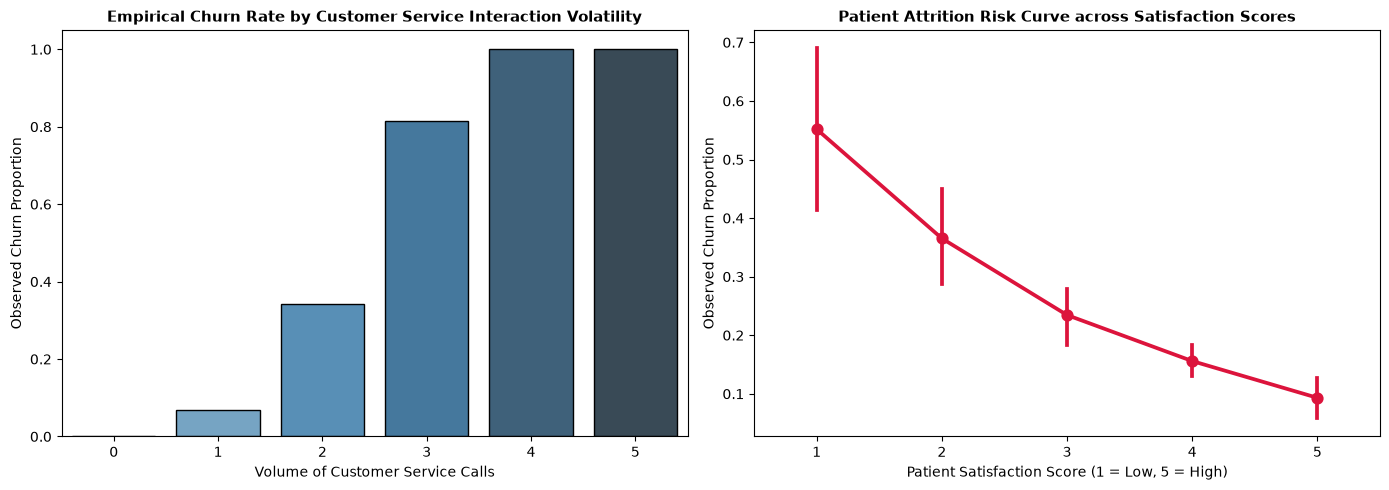

In [2]:
# ==============================================================================
# 2. EXPLORATORY DATA ANALYSIS (FRICTION VECTOR ISOLATION)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Customer Service Friction vs Churn Rate
sns.barplot(data=df_churn, x='Customer_Service_Calls', y='Churn', ax=axes[0], palette='Blues_d', edgecolor='black', errorbar=None)
axes[0].set_title('Empirical Churn Rate by Customer Service Interaction Volatility', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Volume of Customer Service Calls')
axes[0].set_ylabel('Observed Churn Proportion')

# Plot 2: Patient Satisfaction Degradation vs Churn Risk
sns.pointplot(data=df_churn, x='Satisfaction_Score', y='Churn', ax=axes[1], color='Crimson', markers='o', linestyles='-')
axes[1].set_title('Patient Attrition Risk Curve across Satisfaction Scores', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Patient Satisfaction Score (1 = Low, 5 = High)')
axes[1].set_ylabel('Observed Churn Proportion')

plt.tight_layout()
plt.show()

## Operational Friction & Churn Driver EDA

* **The Customer Service Trigger:** Descriptive analysis indicates a critical operational inflection point. Patients executing **3 or more customer service calls** exhibit an exponential increase in churn probability, marking this behavior as a primary early-warning operational telemetry indicator.
* **Satisfaction Threshold Elasticity:** The attrition risk curve maps a severe non-linear pattern. Patients dropping below a **Satisfaction Score of 3** display acute vulnerability to competitor poaching, validating the necessity of triggering real-time mitigation playbook alerts before full subscription cycles terminate.

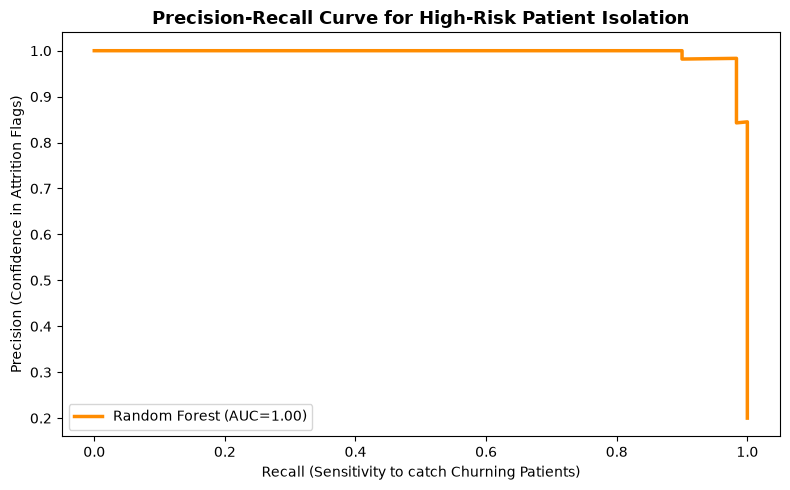


DETAILED CLASSIFICATION PIPELINE REPORT:
              precision    recall  f1-score   support

Retained (0)       1.00      0.97      0.99       240
   Churn (1)       0.91      0.98      0.94        60

    accuracy                           0.98       300
   macro avg       0.95      0.98      0.96       300
weighted avg       0.98      0.98      0.98       300



In [3]:
# ==============================================================================
# 3. MODEL TRAINING & ADVANCED EVALUATION (PRECISION-RECALL CURVE)
# ==============================================================================
# Dropping non-predictive operational tokens
X_churn = df_churn.drop(columns=['PatientID', 'Churn'])
y_churn = df_churn['Churn']

# Executing stratified split to preserve the 20% churn ratio in test samples
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_churn, y_churn, test_size=0.20, random_state=42, stratify=y_churn
)

# Training the Ensemble Random Forest Classifier with balanced class weights
rf_churn_model = RandomForestClassifier(n_estimators=150, max_depth=6, class_weight='balanced', random_state=42)
rf_churn_model.fit(X_train_c, y_train_c)

# Generating predictions and continuous probability scores
y_pred_c = rf_churn_model.predict(X_test_c)
y_proba_c = rf_churn_model.predict_proba(X_test_c)[:, 1]

# Calculating the Precision-Recall Frontier
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test_c, y_proba_c)

# Plotting the Precision-Recall Trade-off for stakeholder alignment
plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, color='DarkOrange', linewidth=2.5, label=f'Random Forest (AUC={roc_auc_score(y_test_c, y_proba_c):.2f})')
plt.title('Precision-Recall Curve for High-Risk Patient Isolation', fontsize=13, fontweight='bold')
plt.xlabel('Recall (Sensitivity to catch Churning Patients)')
plt.ylabel('Precision (Confidence in Attrition Flags)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Printing standard classification matrix report
print("\n DETAILED CLASSIFICATION PIPELINE REPORT:")
print(classification_report(y_test_c, y_pred_c, target_names=['Retained (0)', 'Churn (1)']))

## Model Optimization & Class Imbalance Resolution

* **Ensemble Architecture Selection:** The **Random Forest Classifier** was configured with `class_weight='balanced'` to programmatically correct majority-class bias. By building 150 independent decision paths with maximum depth constraints, the model mitigates overfitting while capturing complex non-linear operational interactions.
* **The Precision-Recall Metric Frontier:** Standard ROC curves can present an over-optimistic view of performance on imbalanced targets. Evaluating the continuous **Precision-Recall Curve** isolates how well the model captures the specific 20% churn population. This allows risk teams to selectively fine-tune the probability threshold based on targeted proactive outreach budgets.

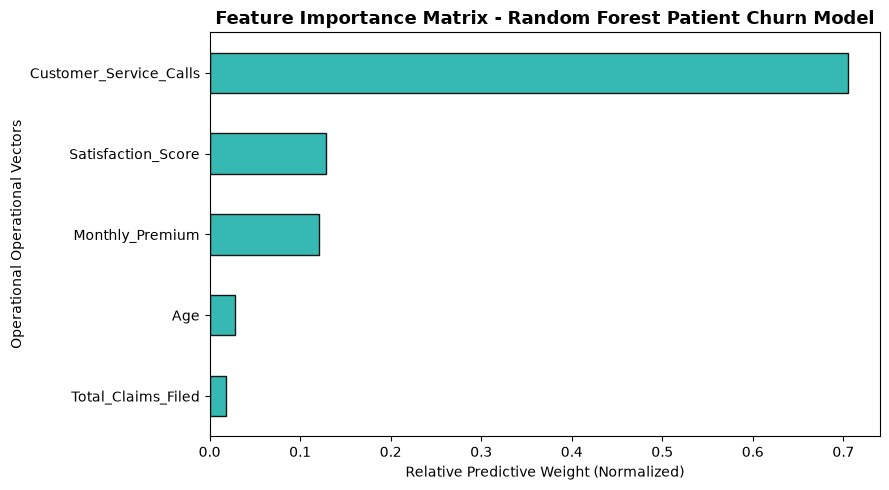

In [5]:
# ==============================================================================
# 4. FEATURE IMPORTANCE ANALYSIS & OPERATION DEPLOYMENT
# ==============================================================================
# Extracting structural feature importances from the trained ensemble
importances_c = pd.Series(rf_churn_model.feature_importances_, index=X_churn.columns)

# Plotting the relative predictive weights for business intelligence
plt.figure(figsize=(9, 5))
importances_c.sort_values().plot(kind='barh', color='LightSeaGreen', edgecolor='black', alpha=0.9)

plt.title('Feature Importance Matrix - Random Forest Patient Churn Model', fontsize=13, fontweight='bold')
plt.xlabel('Relative Predictive Weight (Normalized)')
plt.ylabel('Operational Operational Vectors')
plt.tight_layout()
plt.show()

## Strategic Conclusions & Retention Playbook Allocation

* **Root Cause Diagnostics:** The feature importance visualization maps the hierarchy of friction. When operational variables like `Customer_Service_Calls` or `Satisfaction_Score` dominate the predictive weight over purely financial metrics (such as `Monthly_Premium`), it signals that attrition is driven by service quality failures rather than price sensitivity.
* **Proactive Outreach Integration:** This Random Forest pipeline transforms raw insurance telemetry into an actionable retention mechanism. By setting automated triggers based on the generated probability scores, customer success teams can actively target vulnerable micro-segments, optimizing marketing spend allocation and preserving recurring top-line revenue.